Taller final mecánica de sólidos

![WhatsApp Image 2025-12-14 at 12.23.16 AM.jpeg](<attachment:WhatsApp Image 2025-12-14 at 12.23.16 AM.jpeg>)
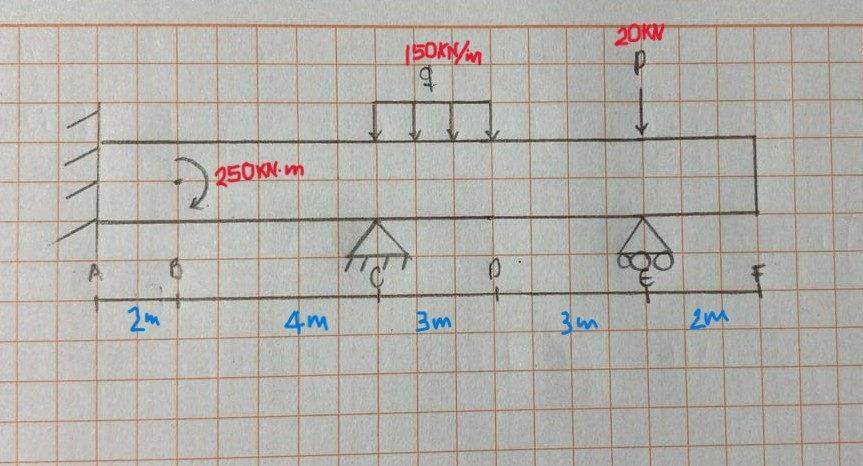

importo librerias

In [32]:
from sympy import lambdify, Piecewise, integrate, symbols, Eq, solve
from sympy.abc import x
from numpy import sum, array, linspace, meshgrid, argmin, argmax, percentile, pi, sqrt, arctan2, unravel_index, maximum, cos, sin, ndarray
import matplotlib.pyplot as plt

# Datos de entrada

Sección transversal:

In [33]:
b  = 0.35            # [m]
h  = 0.50            # [m]
I = (b*h**3)/12     # [m^4] Cálculo de la inercia.

$f'c=21MPa$ (resistencia a compresión del concreto)

$E = 4700 \sqrt{f'c}$ en MPa según la sección C.8.5 de la NSR-10

In [34]:
fpc = 21              # [MPa]
Ei = 4700*(fpc)**0.5  # [MPa]
E = Ei*1000           # [kPa]
nu = 0.23            # Coeficiente de Poisson.
G = E/(2*(1 + nu))   # [kN/m2] Módulo de cortante.

In [35]:
x, y       = symbols("x, y")           # Variables de posición.
C3, C4     = symbols("C3, C4")         # Constantes de integración.
RA, RC, MA, RE = symbols("R_A, R_C, M_A, R_E")  # Reacciones.

In [36]:
# Función con la condición de Macaulay, a: punto de discontinuidad, n:grado
macaulay = lambda a, n : Piecewise(((x-a)**n, (a <= x)), (0, True))

## Ecuaciones de carga, cortante y momento con un corte único

In [37]:
q = - 150*macaulay(6,0) + 150*macaulay(9,0)  # [kN/m] 
V = RA*macaulay(0, 0) +RC*macaulay(6, 0) -150*macaulay(6, 1) +150*macaulay(9, 1) +RE*macaulay(12, 0) -20*macaulay(12, 0)   # [kN]
M = RA*macaulay(0, 1) -MA*macaulay(0, 0) +250*macaulay(2, 0) +RC*macaulay(6, 1) -150/2*macaulay(6, 2) +150/2*macaulay(9, 2) +RE*macaulay(12, 1) -20*macaulay(12, 1)   # [kN.m]

In [38]:
t = integrate(M/(E*I), x) + C3  # [RAD] Ángulo de giro.
v = integrate(t,       x) + C4  # [mm] deflexión con Euler-Bernoulli.

In [39]:
sol = solve([Eq(v.subs(x,0), 0),  # Despl vert en apoyo en x=0 es 0.
             Eq(v.subs(x,6), 0),  # Despl vert en apoyo en x=4 m es 0.
             Eq(v.subs(x,12), 0), # Despl vert en apoyo en x=6 m es 0.
             Eq(RA + RC - 150*3 - 20 + RE, 0),  # Sum fy=0
             Eq(MA - 250 + RC*(6) - 150*3*(6+1.5) + RE*(12) - 20*(12),   0),  # Sum de momentos desde A=0
             Eq(t.subs(x,0), 0),  # Ángulo de giro en x=0 es 0.
             ],
            [RA, RC, C3, C4, MA, RE])

In [40]:
V = V.subs(sol)
M = M.subs(sol)
t = t.subs(sol)
v = v.subs(sol)

In [41]:
xi, yi = meshgrid(linspace(   0,  14, 1000),      # Dirección x.
                  linspace( -h/2, h/2, 1000))  # Dirección y, va de -ci hasta cs.

In [42]:
xg = xi[0]    # Extraemos la información para funciones que sólo dependen de x.
yg = yi[:,0]  # Extraemos la información para funciones que sólo dependen de y.

# Ecuaciones para hallar los esfuerzos y deformaciones 

Calculamos en la malla dada los esfuerzos $\sigma_x$ y $\tau_{xy}$ según la teoría de vigas de Euler-Bernoulli con las ecuaciones:
$$\sigma_x(x,y) = \frac{M(x)y}{I}$$
$$\tau_{xy}(x,y)=\frac{V}{2I}{(y^2-\frac{h^2}{4})}$$

Y usamos la siguiente ecuación válida para vigas con secciones simétricas respecto a $y=0$ para la carga distribuida:

$$\sigma_y(x,y)=\frac{q(x)}{2b(y)h}(2y+h)$$

De este modo, para tener en cuenta las cargas puntuales se tiene en cuenta la solución de Flamant (Seccion 6.13.3 del libro de sólidos):

$$\sigma_y^{puntual} = -\frac{2P}{\pi} \frac{y^3}{((x - x_0)^2 + y^2)^2}$$

In [43]:
sx  = -M*y/I                    # [kN/m2] Esfuerzo normal en x
txy =  V*(y**2-h**2/4)/(2*I)    # [kN/m2] Esfuerzo cortante.

sy_carga = q*(2*y+h)/(2*b*h)          # [kN/m2] Esfuerzo normal en y para cargas distribuidas.

y_flamant_arriba   = (y-h/2)              # [m] Transformación de coordenadas para Flamant.
y_flamant_abajo = (y+h/2)                 # [m] Transformación de coordenadas para Flamant.
sy_p_1      = -2*(sol[RA])/pi*(y_flamant_abajo**3/(((x-0)**2+y_flamant_abajo**2)**2))          # [kN/m2] Esfuerzo normal en y para cargas puntuales.
sy_p_2      = -2*(sol[RC])/pi*(y_flamant_abajo**3/(((x-6)**2+y_flamant_abajo**2)**2))          # [kN/m2] Esfuerzo normal en y para cargas puntuales.
sy_p_3      = -2*(sol[RE])/pi*(y_flamant_abajo**3/(((x-12)**2+y_flamant_abajo**2)**2))         # [kN/m2] Esfuerzo normal en y para cargas puntuales.
sy_p_4      = -2*(-20)/pi*(y_flamant_arriba**3/(((x-12)**2+y_flamant_arriba**2)**2))           # [kN/m2] Esfuerzo normal en y para cargas puntuales.
sy_p       = sy_p_1 + sy_p_2 + sy_p_3 + sy_p_4      # [kN/m2] Esfuerzo normal en y total.

sy = sy_carga        # [kN/m2] Esfuerzo normal en y total.

Debido a que:

$$\displaystyle \underline{\underline{\boldsymbol{\sigma}}} = \left[\begin{matrix}\sigma_{x} & \tau_{xy} & 0\\\tau_{xy} & \sigma_{y} & 0\\0 & 0 & 0\end{matrix}\right]$$

Calculamos las deformaciones con las ecuaciones de **tensión plana** para isótropos:
$$\varepsilon_x=\frac{1}{E}(\sigma_x-\nu \sigma_y)$$

$$\varepsilon_y=\frac{1}{E}(\sigma_y-\nu \sigma_x)$$

$$\varepsilon_z=-\frac{\nu}{E}(\sigma_x+\sigma_y)$$

$$\gamma_{xy}=\frac{1}{G}\tau_{xy}$$

$$\gamma_{yz}=0$$

$$\gamma_{xz}=0$$

In [44]:
ex = (1/E)*(sx - nu*sy)
ey = (1/E)*(sy - nu*sx)
ez = -(nu/E)*(sx + sy)
gxy = txy/G

In [45]:
V  = lambdify(x, V, "numpy")
M  = lambdify(x, M, "numpy")
t  = lambdify(x, t, "numpy")
v  = lambdify(x, v, "numpy")

sx         = lambdify((x,y), sx, "numpy")
txy        = lambdify((x,y), txy, "numpy")
sy_dist    = lambdify((x,y), sy_carga, "numpy")
sy_points  = lambdify((x,y), sy_p, "numpy")
sy         = lambdify((x,y), sy, "numpy")
ex         = lambdify((x,y), ex, "numpy")
ey         = lambdify((x,y), ey, "numpy")
ez         = lambdify((x,y), ez, "numpy")
gxy        = lambdify((x,y), gxy, "numpy")

Calculamos los esfuerzos y direcciones principales a partir de las ecuaciones del capítulo 2:

$$\sigma_1=\frac{(\sigma_x+\sigma_y)}{2}+\tau_{max}$$
$$\sigma_2=\frac{(\sigma_x+\sigma_y)}{2}-\tau_{max}$$

Donde: $\tau_{máx}=R=\sqrt{\left(\frac{\sigma_x-\sigma_y}{2}\right)^2 + \tau_{xy}^2}$

$$\theta_1=\frac{1}{2}\arctan\left(\frac{\tau_{xy}}{\frac{\sigma_x-\sigma_y}{2}}\right)$$

$$\theta_2=\frac{1}{2}\arctan\left(\frac{-\tau_{xy}}{-\frac{\sigma_x-\sigma_y}{2}}\right)$$

In [46]:
# calcular tensiones principales numéricamente sobre la malla
sx_vals  = sx(xi, yi)    # arrays numpy
sy_vals  = sy(xi, yi)
txy_vals = txy(xi, yi)

tmax = sqrt(((sx_vals - sy_vals)/2)**2 + txy_vals**2)
s1   = (sx_vals + sy_vals)/2 + tmax
s2   = (sx_vals + sy_vals)/2 - tmax
t1   = arctan2(txy_vals, (sx_vals - sy_vals)/2)/2
t2   = arctan2(-txy_vals, -(sx_vals - sy_vals)/2)/2

# Gráficos

In [47]:
def grafico_funcion_viga(x, f, titulo, momento=False):
    plt.figure(figsize=(10, 3))                   # Tamaño de la gráfica.
    plt.plot(x, f, 'r')                           # Gráfica de la función.
    plt.fill_between(x, f, color="lavenderblush") # Sombreado de la gráfica.
    plt.plot([0, max(x)], [0, 0], 'k')            # Eje x.
    plt.xlabel("Posición [m]")                   # Título del eje x.
    plt.ylabel(titulo)                            # Título del eje y.
    plt.xlim(0, max(x))                           # Límites en x del gráfico.
    if momento==True:             # Condición si la función es M(x).
        plt.gca().invert_yaxis()  # Invierte el eje y (función).
    plt.show()

def grafico_funcion_esfuerzo_seccion(y, f, titulo):
    plt.figure(figsize=(3, 6))                     # Tamaño de la gráfica.
    plt.plot(f, y, "r")                            # Gráfica de la función.
    plt.fill_betweenx(y,f, color="lavenderblush")  # Sombreado de la gráfica.
    plt.plot([0, 0], [min(y), max(y)], 'k')        # Eje y.
    plt.xlabel(titulo)                             # Título del eje x.
    plt.ylabel("Posición [m]")                    # Título del eje y.
    plt.ylim(min(yg), max(yg))                     # Límites en x del gráfico.
    plt.show()

def dibujar_esf_def(titulo, f, x, y):
    curvas = linspace(f.min(), f.max(), 20)  # Definimos 20 curvas de nivel.
    plt.figure(figsize=(12, 3))
    im = plt.pcolormesh(x, y, f, vmin=f.min(), vmax=f.max(), shading='gouraud', cmap='jet_r')
    # Se grafica la función con colores.
    plt.contour(x, y, f, levels=curvas, colors='k', linestyles='-', linewidths=0.7)
    plt.colorbar(im, aspect=5)       # Se crea una barra de color lateral.
    plt.ylabel(titulo, fontsize=18)  # Título.
    plt.xlim(x.min(), x.max())       # Límites en x del gráfico.
    plt.ylim(y.min(), y.max())       # Límites en y del gráfico.
    plt.show()



## Gráfico de la fuerza cortante

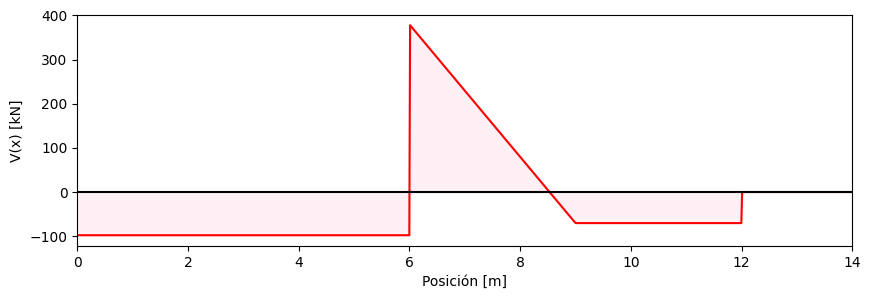

In [48]:
grafico_funcion_viga(xg, V(xg), "V(x) [kN]")

### Maximos, minimos y puntos cero

In [49]:
# Cortante máximo y su posición
V_max = V(xg).max()
pos_V_max = xg[argmax(V(xg))]
print(f"El cortante máximo es V_max = {V_max:.2f} kN en x = {pos_V_max:.2f} m") 

El cortante máximo es V_max = 377.81 kN en x = 6.01 m


In [50]:
# Cortante minimo y su posición
V_min = V(xg).min()
pos_V_min = xg[argmin(V(xg))]
print(f"El cortante mínimo es V_min = {V_min:.2f} kN en x = {pos_V_min:.2f} m")

El cortante mínimo es V_min = -97.89 kN en x = 0.00 m


In [51]:
# Puntos de cortante nulos
# Rango de valores minimos para encontrar los ceros del cortante
xc1 = linspace(0, 10, 1000)
xc2 = linspace(10, 14, 1000)

pos_V_cero_1 = 6                        # Punto de carga puntual
pos_V_cero_2 = xc1[argmin(abs(V(xg)))]
pos_V_cero_3 = xc2[argmin(abs(V(xg)))]
print(f"Los puntos de cortante nulo están en x = {pos_V_cero_1:.2f} m, en x = {pos_V_cero_2:.2f} m y en x = {pos_V_cero_3:.2f} m")

Los puntos de cortante nulo están en x = 6.00 m, en x = 8.58 m y en x = 13.43 m


## Gráfico de momento flector

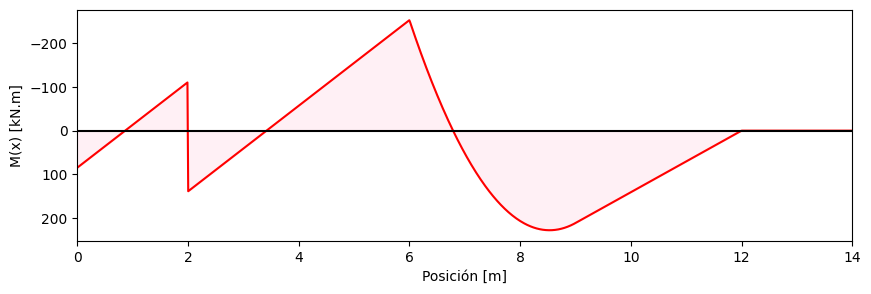

In [52]:
grafico_funcion_viga(xg, M(xg), "M(x) [kN.m]", momento=True)

### Maximos, minimos y puntos cero

In [53]:
# Momento máximo y su posición
M_max = M(xg).max()
pos_M_max = xg[argmax(M(xg))]
print(f"El momento máximo es M_max = {M_max:.2f} kN.m en x = {pos_M_max:.2f} m")

El momento máximo es M_max = 227.67 kN.m en x = 8.53 m


In [54]:
# Momento minimo y su posición
M_min = M(xg).min()
pos_M_min = xg[argmin(M(xg))]
print(f"El momento mínimo es M_min = {M_min:.2f} kN.m en x = {pos_M_min:.2f} m")

El momento mínimo es M_min = -252.48 kN.m en x = 6.00 m


In [55]:
# Puntos de momento nulos 
# Rango de valores minimos para encontrar los ceros del momento
x1 = linspace(0.000001, 1.99999, 1000)
x2 = linspace(2.0001, 6, 1000)
x3 = linspace(6.0001, 11, 1000)
x4 = linspace(12, 14, 1000)

pos_M_cero_1 = x1[argmin(abs(M(x1)))]
pos_M_cero_2 = 2                        # Punto de momento aplicado
pos_M_cero_3 = x2[argmin(abs(M(x2)))]
pos_M_cero_4 = x3[argmin(abs(M(x3)))]
pos_M_cero_5 = x4[argmin(abs(M(x4)))]
print(f"Los puntos de momento nulo están en x = {pos_M_cero_1:.2f} m, x = {pos_M_cero_2:.2f} m, x = {pos_M_cero_3:.2f} m, x = {pos_M_cero_4:.2f} m y x = {pos_M_cero_5:.2f} m")


Los puntos de momento nulo están en x = 0.86 m, x = 2.00 m, x = 3.42 m, x = 6.79 m y x = 12.00 m


## Grafico de la deformada de la viga

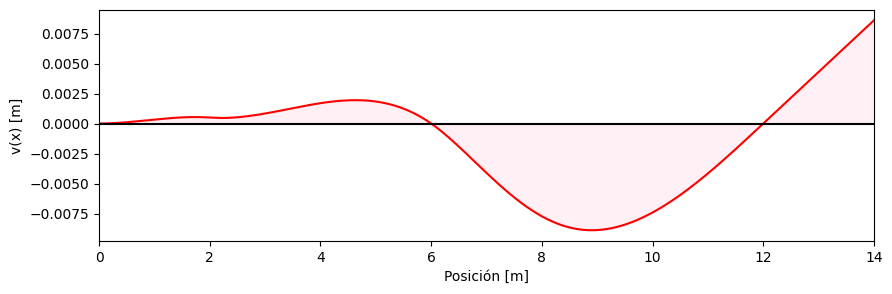

In [56]:
grafico_funcion_viga(xg, v(xg), "v(x) [m]")

## Gráfico esfuerzo normal en x

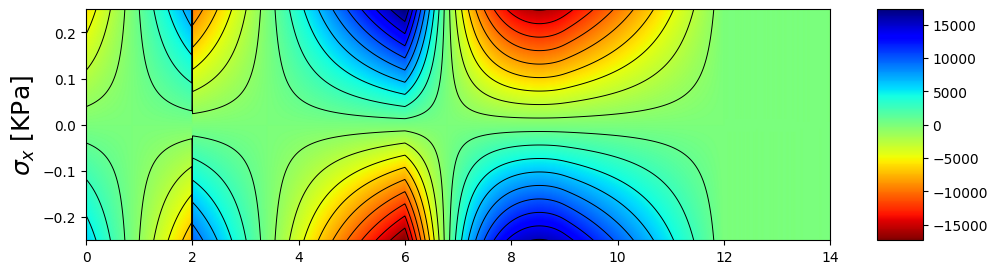

In [57]:
dibujar_esf_def(r"$\sigma_x$ [KPa]", sx(xi,yi), xi, yi)

Maximos, minimos y puntos cero

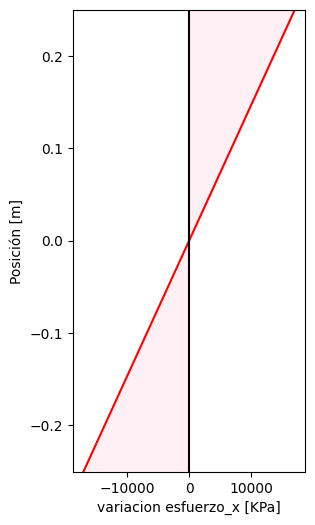

El esfuerzo normal máximo en x es sx_max = 17313.09 kPa
El esfuerzo normal mínimo en x es sx_min = -17313.09 kPa
El esfuerzo normal maximo y minimo se presenta en la coordenada de X donde el momento es maximo absoluto para una sección rectangular 
Así mismo, el esfuerzo normal es nulo en los puntos donde el momento es nulo (especificados anteriormente) y en la fibra neutra de la sección


In [58]:
grafico_funcion_esfuerzo_seccion(yg, sx(pos_V_max,yg), r"variacion esfuerzo_x [KPa]")

# Máximo y mínimo esfuerzo normal en x
sx_max = sx(pos_M_min, yg).max()
sx_min = sx(pos_M_min, yg).min()
print(f"El esfuerzo normal máximo en x es sx_max = {sx_max:.2f} kPa")
print(f"El esfuerzo normal mínimo en x es sx_min = {sx_min:.2f} kPa")
print("El esfuerzo normal maximo y minimo se presenta en la coordenada de X donde el momento es maximo absoluto para una sección rectangular", 
      "\nAsí mismo, el esfuerzo normal es nulo en los puntos donde el momento es nulo (especificados anteriormente) y en la fibra neutra de la sección")

## Gráfico esfuerzo normal en Y

Es importante resaltar que, debido a la disparidad en las magnitudes del esfuerzo normal $\sigma_y$ entre la carga distribuida y las cargas puntuales (Flamant), se procedió a graficar cada caso por separado para facilitar su visualización. Para el resto del análisis, se utilizará exclusivamente el valor de $\sigma_y$ generado por la carga distribuida, asumiendo que la influencia de las cargas puntuales se restringe a zonas muy localizadas y no altera la distribución general de esfuerzos en el resto del elemento.

### Esfuerzo normal en Y para la carga distribuida

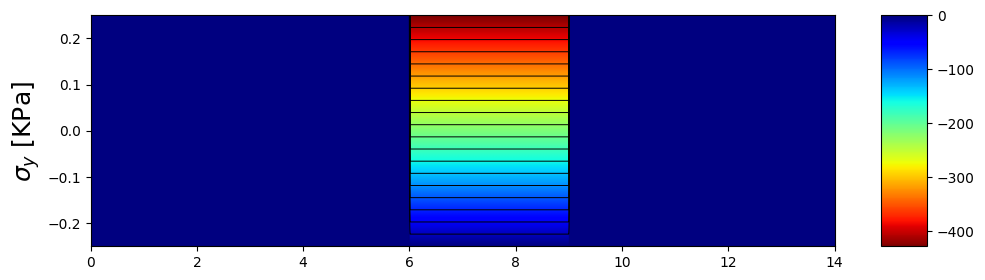

In [59]:
dibujar_esf_def(r"$\sigma_y$ [KPa]", sy_dist(xi,yi), xi, yi)

El gráfico de la carga distribuida muestra una variación suave y predecible donde el esfuerzo máximo en la superficie es exactamente igual a la presión aplicada ($q/b$). Siendo así que, satisface perfectamente las condiciones de frontera en la altura: $\sigma_y$ es máximo en la cara superior y estrictamente cero en la cara inferior.

### Esfuerzo normal en Y para las cargas puntuales

<lambdifygenerated-21>:2: RuntimeWarning: invalid value encountered in divide
  return 12.7323954473516*(y - 0.25)**3/((x - 12)**2 + (y - 0.25)**2)**2 - 303.989099141693*(y + 0.25)**3/((x - 6)**2 + (y + 0.25)**2)**2 - 57.5420907345339*(y + 0.25)**3/((x - 12)**2 + (y + 0.25)**2)**2 + 62.3198968634637*(y + 0.25)**3/(x**2 + (y + 0.25)**2)**2


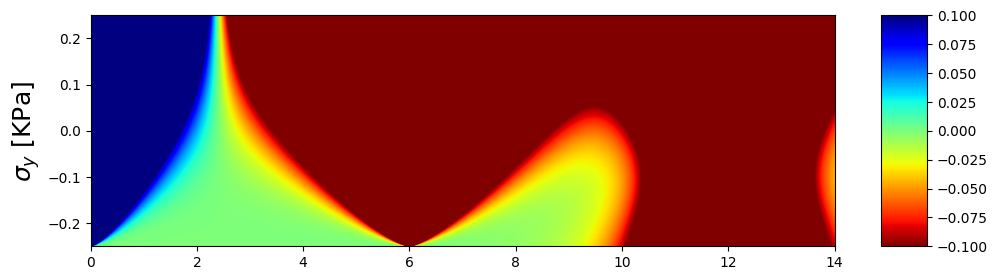

In [60]:
dibujar_esf_def(r"$\sigma_y$ [KPa]", sy_points(xi,yi), xi, yi)

A pesar de que las cargas distribuidas dominan el estado de esfuerzos global, las cargas puntuales generan concentraciones que, aunque se disipan rápidamente (validando a Saint-Venant), no deben ignorarse por completo. Si bien es cierto que su influencia se vuelve despreciable lejos del punto de aplicación, la intensidad local de estos esfuerzos es determinante: si excede los límites admisibles, puede provocar fallas localizadas como el punzonamiento, aun cuando no afecte la flexión general de la estructura.

## Gráfico esfuerzo cortante

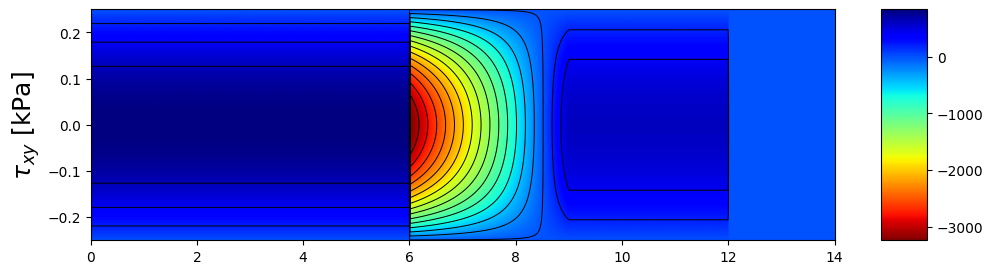

In [61]:
dibujar_esf_def(r"$\tau_{xy}$ [kPa]", txy(xi,yi), xi, yi)

Maximos, minimos y puntos cero

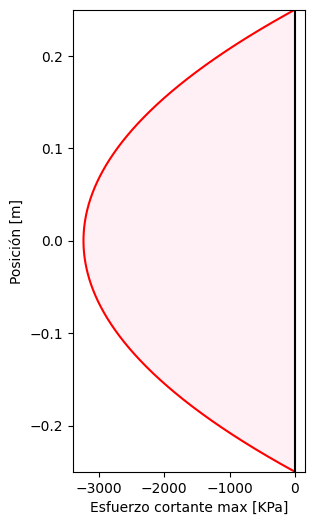

El esfuerzo cortante minimo es txy = -3238.38 kPa


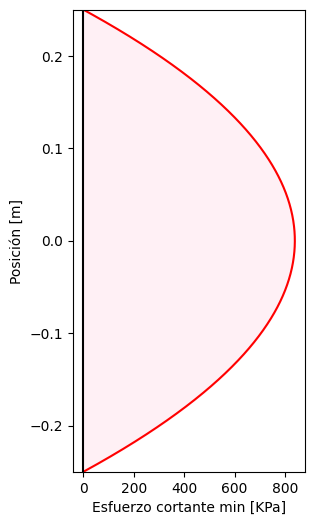

El esfuerzo cortante máximo es txy = 839.07 kPa 
Se concluye tambien que el esfuerzo cortante es nulo en los puntos donde la fuerza cortante es nula y en los extremos de la sección


In [62]:
grafico_funcion_esfuerzo_seccion(yg, txy(pos_V_max,yg), r"Esfuerzo cortante max [KPa]")

# Minimo esfuerzo cortante
txy_min = txy(pos_V_max, yg).min()
print(f"El esfuerzo cortante minimo es txy = {txy_min:.2f} kPa")

grafico_funcion_esfuerzo_seccion(yg, txy(pos_V_min,yg), r"Esfuerzo cortante min [KPa]")

# Maximo esfuerzo cortante
txy_max = txy(pos_V_min, yg).max()
print(f"El esfuerzo cortante máximo es txy = {txy_max:.2f} kPa",
      "\nSe concluye tambien que el esfuerzo cortante es nulo en los puntos donde la fuerza cortante es nula y en los extremos de la sección")

## Gráfico de deformacion longitudinal en X

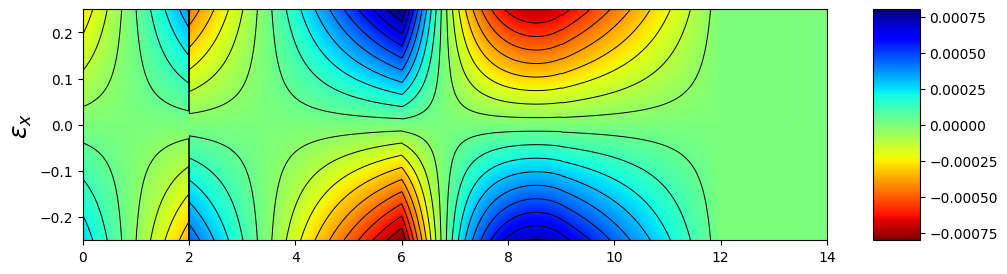

In [63]:
dibujar_esf_def(r"$\varepsilon_x$", ex(xi,yi), xi, yi)

Máximos y minimos

In [64]:
def find_extremos_deformacion(func_2d, xi, yi, nombre="deformación"):
    vals = func_2d(xi, yi)
    
    imax, jmax = unravel_index(argmax(vals), vals.shape)
    imin, jmin = unravel_index(argmin(vals), vals.shape)
    
    x_max, y_max = xi[imax, jmax], yi[imax, jmax]
    x_min, y_min = xi[imin, jmin], yi[imin, jmin]
    
    val_max = vals[imax, jmax]
    val_min = vals[imin, jmin]
    
    print(f"{nombre} máximo = {val_max:.6e} en x = {x_max:.4f} m, y = {y_max:.4f} m")
    print(f"{nombre} mínimo = {val_min:.6e} en x = {x_min:.4f} m, y = {y_min:.4f} m")
    
    return {"max": val_max, "x_max": x_max, "y_max": y_max,
            "min": val_min, "x_min": x_min, "y_min": y_min}

res_ex = find_extremos_deformacion(ex, xi, yi, "εx")


εx máximo = 8.038354e-04 en x = 5.9980 m, y = 0.2500 m
εx mínimo = -8.038354e-04 en x = 5.9980 m, y = -0.2500 m


Tal como ocurre con el esfuerzo normal $\sigma_x$, las deformaciones longitudinales ($\varepsilon_x$) se anulan en la fibra neutra y en los puntos de momento nulo. Esta coincidencia se explica por la gran diferencia de magnitud entre ambos esfuerzos principales: $\sigma_x$ domina el comportamiento, mientras que el efecto de $\sigma_y$ resulta marginal, al ser no solo más pequeño, sino también atenuado por el coeficiente de Poisson en la ecuación constitutiva. Por tanto, los puntos de deformación nula en X coinciden con los puntos de esfuerzo nulo en esa misma dirección.

## Gráfico de deformación longitudinal en Y

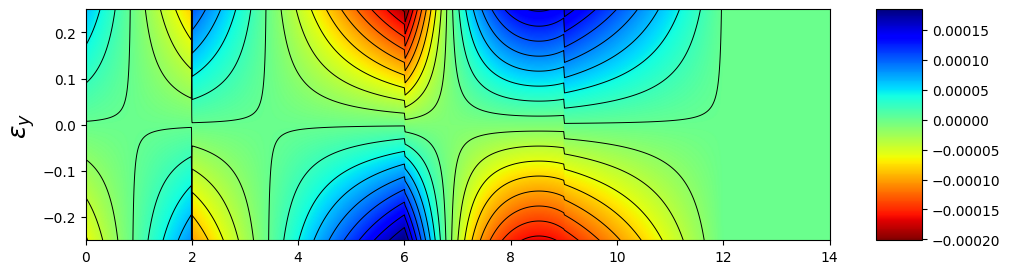

In [65]:
dibujar_esf_def(r"$\varepsilon_y$", ey(xi,yi), xi, yi)

Máximos y minimos

In [66]:
res_ey = find_extremos_deformacion(ey, xi, yi, "εy")

εy máximo = 1.848821e-04 en x = 5.9980 m, y = -0.2500 m
εy mínimo = -2.015928e-04 en x = 6.0120 m, y = 0.2500 m


Al igual que ocurre con $\varepsilon_x$, las deformaciones verticales $\varepsilon_y$ tienden a anularse en la fibra neutra y puntos de momento nulo. Este comportamiento se explica principalmente por el Efecto de Poisson: dado que $\sigma_x$ es el esfuerzo dominante en la mayor parte de la luz (especialmente para $x < 6$ y $x > 9$ m), este induce una deformación transversal proporcional. Sin embargo, a diferencia del análisis en X, aquí se observa una influencia directa y no despreciable del esfuerzo normal $\sigma_y$ en la zona de aplicación de carga distribuida. Por tanto, la coincidencia entre puntos de esfuerzo nulo y deformación nula se mantiene, excepto bajo las cargas concentradas donde $\sigma_y$ gobierna localmente la deformación.

## Gráfico de deformacion longitudinal en Z

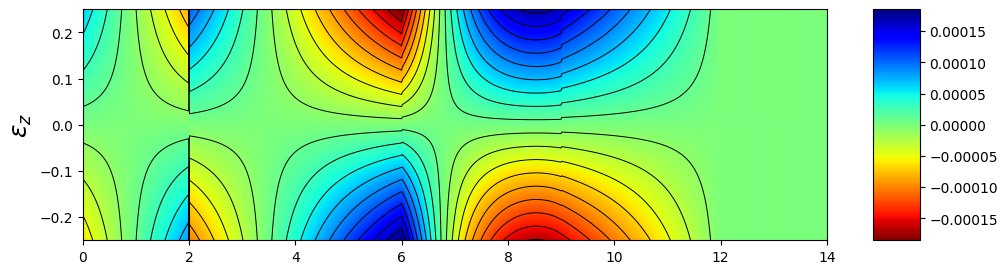

In [67]:
dibujar_esf_def(r"$\varepsilon_z$", ez(xi,yi), xi, yi)

Máximos y minimos

In [68]:
res_ez = find_extremos_deformacion(ez, xi, yi, "εz")

εz máximo = 1.848821e-04 en x = 5.9980 m, y = -0.2500 m
εz mínimo = -1.848821e-04 en x = 5.9980 m, y = 0.2500 m


Dado que el análisis se enmarca en condiciones de Tensión Plana ($\sigma_z = 0$), la deformación en dirección Z ($\varepsilon_z$) no se debe a cargas directas en ese eje, sino que surge exclusivamente como respuesta al Efecto de Poisson. Al igual que se observó con $\varepsilon_y$, la distribución de $\varepsilon_z$ está gobernada por la predominancia del esfuerzo longitudinal $\sigma_x$ sobre el resto de componentes. En consecuencia, los puntos de deformación nula ($\varepsilon_z \approx 0$) coinciden casi perfectamente con los puntos de esfuerzo nulo de $\sigma_x$ (fibra neutra y momentos cero), ya que la deformación transversal es simplemente una función escalada del esfuerzo longitudinal dominante.

## Gráfico deformación angular

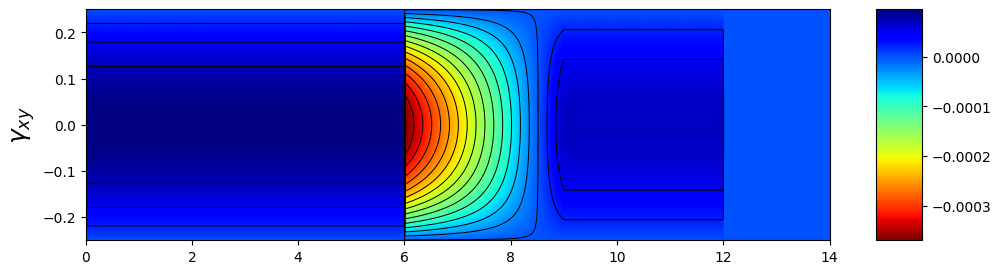

In [69]:
dibujar_esf_def(r"$\gamma_{xy}$", gxy(xi,yi), xi, yi)

In [70]:
res_ex = find_extremos_deformacion(gxy, xi, yi, "γxy")

γxy máximo = 9.583563e-05 en x = 0.0000 m, y = -0.0003 m
γxy mínimo = -3.698753e-04 en x = 6.0120 m, y = -0.0003 m


Dados los resultados obtenidos en el gráfico del esfuerzo cortante y ahora de la deformacion angular, se puede concluir que los resultados son análogos si nos basamos en la escala de colores presente y la similitud de ambos gráficos, esto debido a que al pasar de una variable a la otra por medio de la ley de Hooke, el resultado es basicamente dividir los valores obtenidos entre un coeficiente como lo es el modulo de cortante. De este modo, los puntos donde la deformación $\gamma_{xy}$ es maxima, minima o nula son aproximadamente los mismos encontrados en el analisis del esfuerzo cortante $\tau_{xy}$, y por ende los mismos puntos especificados en el analisis del gráfico de la fuerza cortante.

# Esfuerzos principales

## Esfuerzos principales y sus direcciones

In [71]:
# Revisión de valores en el punto donde σ1 es máximo
imax, jmax = unravel_index(argmax(s1), s1.shape)
x_pt = xi[imax, jmax]
y_pt = yi[imax, jmax]

print(f"En el punto máximo de σ1 (x={x_pt:.4f}, y={y_pt:.4f}):")
print(f"σx = {sx_vals[imax, jmax]:.2f} kPa")
print(f"σy = {sy_vals[imax, jmax]:.2f} kPa")
print(f"τxy = {txy_vals[imax, jmax]:.2f} kPa")
print(f"σ1 = {s1[imax, jmax]:.2f} kPa")
print("La dirección de σ1 con respecto al eje x es =", t1[imax, jmax]*180/pi, "grados")

En el punto máximo de σ1 (x=5.9980, y=0.2500):
σx = 17313.09 kPa
σy = 0.00 kPa
τxy = -0.00 kPa
σ1 = 17313.09 kPa
La dirección de σ1 con respecto al eje x es = -0.0 grados


In [72]:
# Revisión de valores en el punto donde σ2 es minimo
imin, jmin = unravel_index(argmin(s2), s2.shape)
x_pt2 = xi[imin, jmin]
y_pt2 = yi[imin, jmin]

print(f"En el punto minimo de σ2 (x={x_pt2:.4f}, y={y_pt2:.4f}):")
print(f"σx = {sx_vals[imin, jmin]:.2f} kPa")
print(f"σy = {sy_vals[imin, jmin]:.2f} kPa")
print(f"τxy = {txy_vals[imin, jmin]:.2f} kPa")
print(f"σ2 = {s2[imin, jmin]:.2f} kPa")
print("La dirección de σ2 con respecto al eje x es =", t2[imin, jmin]*180/pi, "grados")

En el punto minimo de σ2 (x=5.9980, y=-0.2500):
σx = -17313.09 kPa
σy = 0.00 kPa
τxy = -0.00 kPa
σ2 = -17313.09 kPa
La dirección de σ2 con respecto al eje x es = 0.0 grados


Se concluye que los resultados anteriores se deben a la gran influencia del momento obtenido en en la coordenada x=6 m, lo cual conlleva a que los mayores esfuerzos se presenten alrededor de esta zona.

## Esfuerzo equivalente de Von Mises

Para un caso de Tensión Plana como el que se está trabajando (donde $\sigma_z = 0$), la fórmula es (seccion 16.6.5):$$\sigma_{VM} = \sqrt{((\sigma_1-\sigma_2)^2 + (\sigma_1)^2 + (\sigma_2)^2)/2}$$

In [73]:
# Esfuerzo equivalente de Von Mises
s_vm = sqrt(((s1 - s2)**2 +(s1)**2 + (s2)**2)/2)

# Evaluar si el esfuerzo equivalente de Von Mises supera la resistencia del material
s_vm_max = s_vm.max()
print(f"El esfuerzo equivalente de Von Mises máximo es s_vm_max = {s_vm_max:.2f} kPa")
if s_vm_max > fpc*1000:
    print(f"El material falla bajo el criterio de Von Mises. Esto debido a que {s_vm_max:.2f} kPa > {fpc*1000} kPa")
else:
    print(f"El material no falla bajo el criterio de Von Mises. Esto debido a que {s_vm_max:.2f} kPa ≤ {fpc*1000} kPa")


El esfuerzo equivalente de Von Mises máximo es s_vm_max = 17313.09 kPa
El material no falla bajo el criterio de Von Mises. Esto debido a que 17313.09 kPa ≤ 21000 kPa


## Esfuerzo equivalente de Tresca

El Criterio de Tresca considera el esfuerzo cortante máximo absoluto. Como $\sigma_z=0$ se aplica para tension plana, el esfuerzo equivalente de Tresca es la mayor diferencia entre cualquiera de los tres principales (seccion 16.6.5) ($\sigma_1, \sigma_2, 0$):$$\sigma_{Tresca} = (\max\left( |\sigma_1 - \sigma_2|, |\sigma_1 - 0|, |\sigma_2 - 0| \right))/2$$

In [74]:
# Esfuerzo equivalente de Tresca
s_tresca = maximum(abs(s1), abs(s2), abs(s1 - s2))/2

# Evaluar si el esfuerzo equivalente de Tresca supera la resistencia del material
s_tresca_max = s_tresca.max()
print(f"El esfuerzo equivalente de Tresca máximo es s_tresca_max = {s_tresca_max:.2f} kPa")
if s_tresca_max > fpc*1000:
    print(f"El material falla bajo el criterio de Tresca. Esto debido a que {s_tresca_max:.2f} kPa > {fpc*1000} kPa")
else:
    print(f"El material no falla bajo el criterio de Tresca. Esto debido a que {s_tresca_max:.2f} kPa ≤ {fpc*1000} kPa")

El esfuerzo equivalente de Tresca máximo es s_tresca_max = 8656.55 kPa
El material no falla bajo el criterio de Tresca. Esto debido a que 8656.55 kPa ≤ 21000 kPa


## Patrón de agrietamiento aproximado de la viga

In [75]:
def dibujar_esf_def2(titulo, f, x, y, angulo=None):
    # 1. Configuración de niveles (usando percentiles para evitar picos extremos)
    vmin, vmax = percentile(f, 2), percentile(f, 98)
    curvas = linspace(vmin, vmax, 20)
    
    plt.figure(figsize=(20, 4))
    
    # 2. Graficar el mapa de colores (fondo)
    # Usamos toda la resolución original para el color
    im = plt.pcolormesh(x, y, f, vmin=vmin, vmax=vmax, shading='gouraud', cmap='jet_r')
    
    # 3. Graficar las líneas de dirección (trayectorias)
    if angulo is not None:
        # 'paso' define cada cuántos puntos dibujamos una línea.
        # Aumenta este número si aún se ve muy negro (ej. 8, 10, 15)
        paso = 60
        
        # Creamos sub-matrices saltando índices [inicio:fin:paso]
        x_sub = x[::paso, ::paso]
        y_sub = y[::paso, ::paso]
        f_sub = f[::paso, ::paso]
        
        # Manejo de lista de ángulos
        if isinstance(angulo, ndarray):
            angulo = [angulo]
            
        for ang in angulo:
            # Recortamos también el ángulo con el mismo paso
            ang_sub = ang[::paso, ::paso]
            
            # Calculamos componentes U y V
            # Nota: Tu escala original abs(f)**(1/3) está bien para suavizar diferencias
            escala_ang = abs(f_sub)**(1/3)
            
            u = escala_ang * cos(ang_sub)
            v = escala_ang * sin(ang_sub)
            
            # Graficamos con quiver
            # scale: Controla la longitud (mayor número = flechas más cortas)
            # width: Grosor de la línea
            plt.quiver(x_sub, y_sub, u, v,
                       headwidth=0, headlength=0, headaxislength=0, # Sin cabeza de flecha
                       pivot="middle", color='k', 
                       scale=160, width=0.0015, alpha=0.6)

    # 4. Contornos y decoración
    plt.contour(x, y, f, levels=curvas, colors='k', linestyles='-', linewidths=0.5, alpha=0.3)
    
    cbar = plt.colorbar(im, aspect=10)
    plt.ylabel(titulo, fontsize=18)
    plt.xlim(x.min(), x.max())
    plt.ylim(y.min(), y.max())
    plt.show()

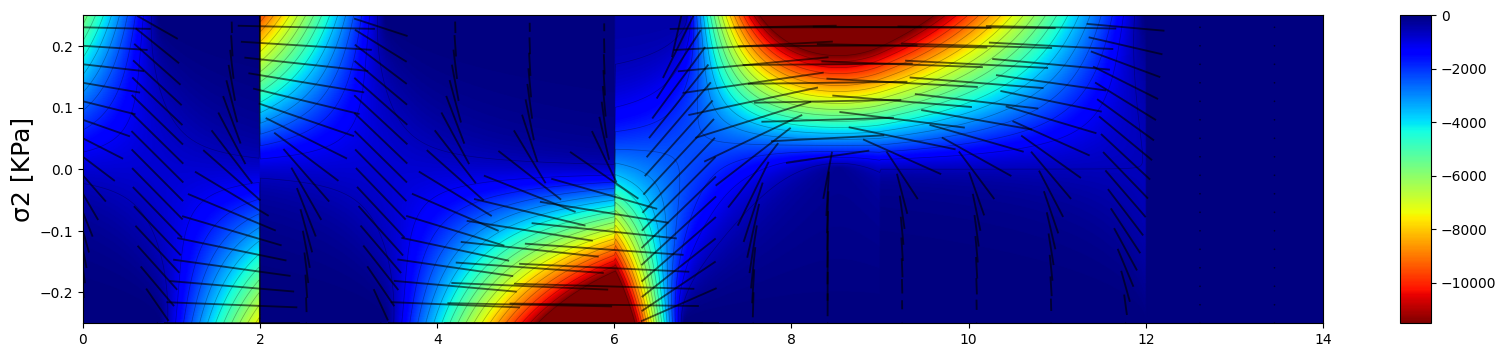

In [76]:
# Patron de agrietamiento aproximado, es decir, trayectorias de maxima compresion 

dibujar_esf_def2(r"σ2 [KPa]", s2, xi, yi, t2)

## Refuerzo optimo aproximado 

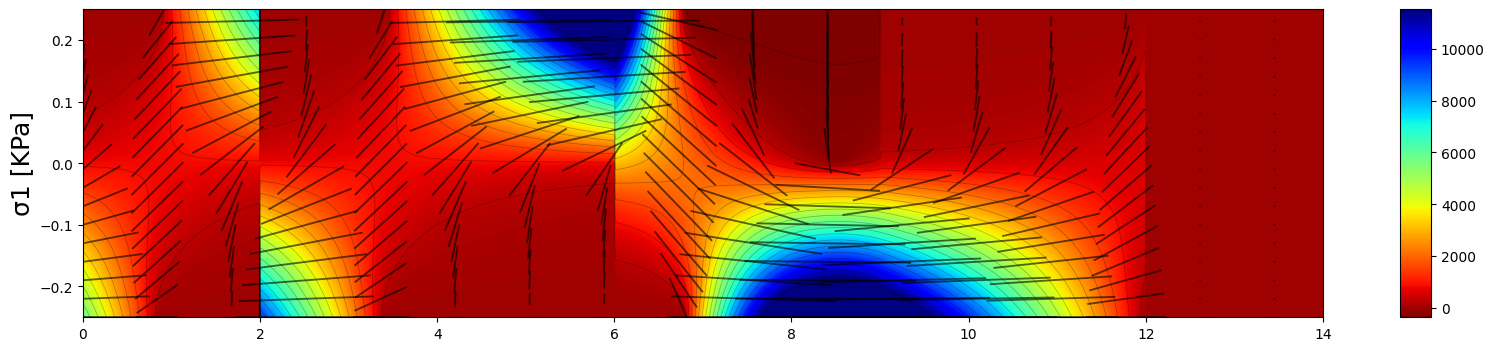

In [77]:
# Refuerzo optimo aproximado, es decir, trayectorias de maxima tension

dibujar_esf_def2(r"σ1 [KPa]", s1, xi, yi, t1)

## Refuerzo convencional aproximado 

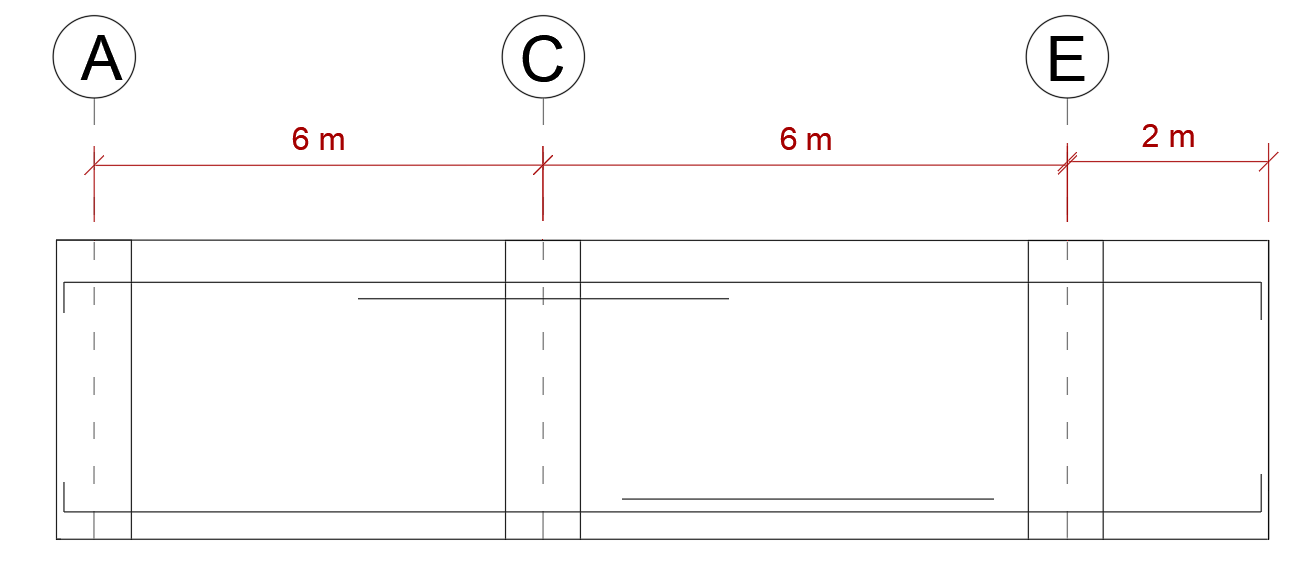

Se propone el tipo de refuerzo longitudinal dado para resistir los esfuerzos y momentos aplicados en los puntos criticos como lo son los apoyos que deben resistir esfuerzos de grandes magnitudes en la parte superior y la mitad de la luz C-E. Por lo cual, se propone el uso de un refuerzo extra en estas zonas que servirá para el manejo del momento flector en estos puntos.